In [1]:
%matplotlib inline

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import math

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt


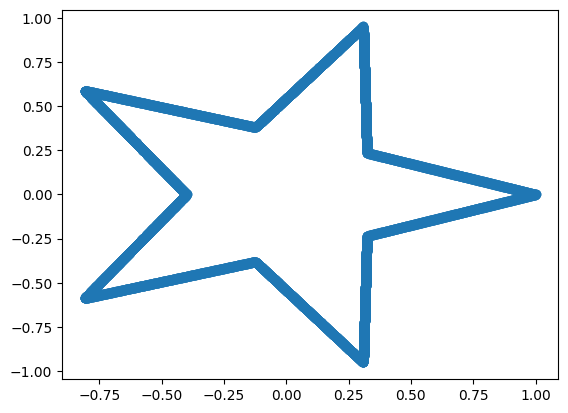

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=1000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius

        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])
    vertices.append(vertices[0])

    vertices = np.array(vertices)
    sampled_points = []

    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]

        for t in np.linspace(0, 1, n_samples // (len(vertices) - 1)):
            point = (1 - t) * start_point + t * end_point
            sampled_points.append(point)

    return np.array(sampled_points)


s = generate_star(n_samples=5000)

plt.scatter(s[:, 0], s[:, 1])
plt.show()

In [3]:
class Config:
    beta_min = 0.01
    beta_max = 2.0
    schedule = 'linear'  # 'linear' or 'cosine'
    mode = 'sigma2'      # uniform, sigma2, beta, inv_sigma2

    lr = 1e-3
    epochs = 2000
    batch_size = 512
    hidden_dim = 256
    num_timesteps = 1000
    data_samples = 5000


In [4]:
class ScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()

        self.config = config

        self.time_embed = nn.Sequential(
            nn.Linear(1, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim)
        )

        self.net = nn.Sequential(
            nn.Linear(2 + config.hidden_dim, config.hidden_dim),
            nn.ReLU(),
            nn.Linear(config.hidden_dim, 2)
        )

    def forward(self, x, t):
        t_embed = self.time_embed(t)
        x_input = torch.cat([x, t_embed], dim=1)

        return self.net(x_input)

In [5]:
# --- Linear VP-SDE schedule ---

def beta_t(t, config):
    return config.beta_min + t * (config.beta_max - config.beta_min)


def log_alpha_t(t, config):
    return -0.25 * (config.beta_max - config.beta_min) * t ** 2 - 0.5 * config.beta_min * t


def alpha_t(t, config):
    return torch.exp(log_alpha_t(t, config))


def std_t(t, config):
    a = alpha_t(t, config)
    return torch.sqrt(1.0 - a ** 2 + 1e-5)


# --- Cosine VP-SDE schedule ---

def cosine_alpha_bar_t(t, s=0.008):
    t = torch.clamp(t, 0.0, 1.0)
    f_t = torch.cos((t + s) / (1 + s) * torch.pi / 2) ** 2
    f_0 = torch.cos(torch.tensor(s / (1 + s) * torch.pi / 2, device=t.device)) ** 2
    return f_t / f_0


def cosine_alpha_t(t, config=None, s=0.008):
    alpha_bar = cosine_alpha_bar_t(t, s=s)
    return torch.sqrt(torch.clamp(alpha_bar, min=1e-6, max=1.0))


def cosine_std_t(t, config=None, s=0.008):
    alpha_bar = cosine_alpha_bar_t(t, s=s)
    return torch.sqrt(torch.clamp(1.0 - alpha_bar, min=1e-6, max=1.0))


def cosine_beta_t(t, config=None, s=0.008):
    t = torch.clamp(t, 1e-5, 1.0 - 1e-5)
    u = (t + s) / (1 + s)
    beta = (torch.pi / (1 + s)) * torch.tan(u * torch.pi / 2)
    return torch.clamp(beta, max=50.0)


def get_schedule_functions(schedule):
    if schedule == 'linear':
        return alpha_t, std_t, beta_t
    if schedule == 'cosine':
        return cosine_alpha_t, cosine_std_t, cosine_beta_t
    raise ValueError(f"Unknown schedule: {schedule}")


In [6]:
def loss_weight(t, sigma, config, mode='uniform', eps=1e-4):
    if mode == 'uniform':
        w = torch.ones_like(t)
    elif mode == 'sigma2':
        w = sigma ** 2
    elif mode == 'beta':
        w = beta_t(t, config)
    elif mode == 'inv_sigma2':
        w = 1.0 / torch.clamp(sigma ** 2, min=eps)
        w = torch.clamp(w, min=0.0, max=100.0)
        w = w / w.mean().detach()
    else:
        raise ValueError(f"Unknown loss mode: {mode}")
    return w


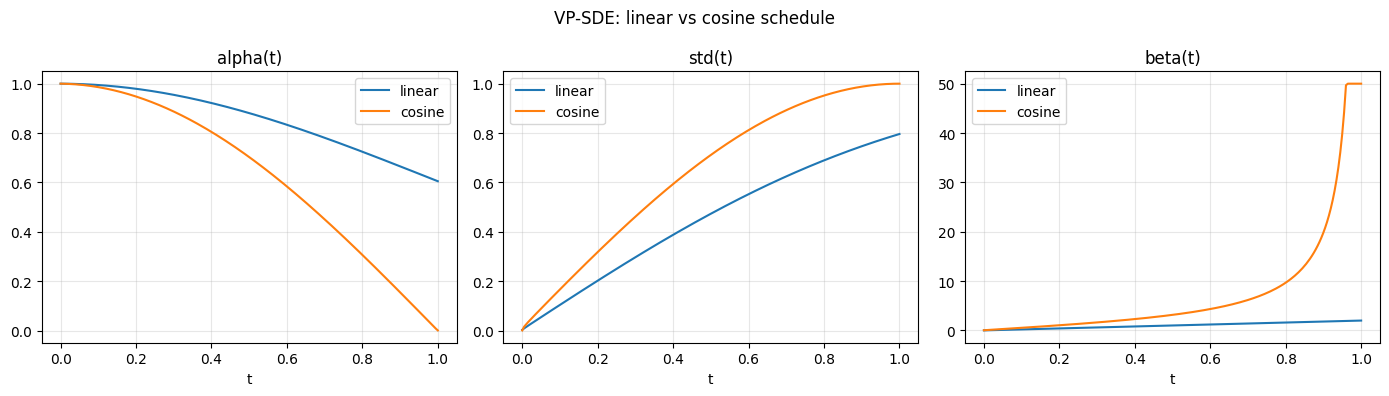

In [7]:
def plot_schedules(config, n_points=200):
    t = torch.linspace(0, 1, n_points).unsqueeze(1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for schedule, color in [('linear', 'C0'), ('cosine', 'C1')]:
        alpha_fn, std_fn, beta_fn = get_schedule_functions(schedule)
        a = alpha_fn(t, config).squeeze().numpy()
        s = std_fn(t, config).squeeze().numpy()
        b = beta_fn(t, config).squeeze().numpy()
        axes[0].plot(t.squeeze().numpy(), a, color=color, label=schedule)
        axes[1].plot(t.squeeze().numpy(), s, color=color, label=schedule)
        axes[2].plot(t.squeeze().numpy(), b, color=color, label=schedule)

    axes[0].set_title('alpha(t)')
    axes[1].set_title('std(t)')
    axes[2].set_title('beta(t)')
    for ax in axes:
        ax.set_xlabel('t')
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.suptitle('VP-SDE: linear vs cosine schedule')
    plt.tight_layout()
    plt.show()


config = Config()
plot_schedules(config)


In [8]:
class VPTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
        self.mode = config.mode
        self.alpha_fn, self.std_fn, self.beta_fn = get_schedule_functions(config.schedule)

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)

        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = ScoreModel(config).to(self.device)
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)
            t = torch.rand(batch.shape[0], 1, device=self.device)

            a = self.alpha_fn(t, self.config)
            s = self.std_fn(t, self.config)

            z = torch.randn_like(batch)
            x_t = a * batch + s * z

            pred_z = self.model(x_t, t)
            w = loss_weight(t, s, self.config, mode=self.mode)
            per_sample = ((pred_z - z) ** 2).mean(dim=1, keepdim=True)
            loss = (w * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self):
        history = []
        for n in range(self.config.epochs):
            loss = self.train_epoch()
            history.append(loss)
            if n % 100 == 0:
                print(f'[{self.config.schedule}] epoch {n}: loss={loss:.4f}')
        return history


In [9]:
def sample_vp(model, config, num_samples=1000):
    device = torch.device('cuda') if torch.cuda.is_available() else 'cpu'
    _, std_fn, beta_fn = get_schedule_functions(config.schedule)

    model.eval()
    with torch.no_grad():
        x = torch.randn(num_samples, 2, device=device)
        dt = 1.0 / config.num_timesteps

        for i in range(config.num_timesteps):
            t = max(1.0 - i * dt, 1e-6)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta = beta_fn(t_tensor, config)
            std = std_fn(t_tensor, config)

            pred = model(x, t_tensor)
            score = -pred / std

            drift = (0.5 * beta * x + beta * score) * dt
            diffusion = torch.sqrt(torch.clamp(beta, min=1e-5)) * torch.randn_like(x) * math.sqrt(dt)
            x = x + drift + diffusion

        return x.cpu().numpy()


## Обучение VP-SDE: linear schedule


In [10]:
config_linear = Config()
config_linear.schedule = 'linear'
config_linear.mode = 'sigma2'

trainer_linear = VPTrainer(config_linear)
losses = {}
losses['linear'] = trainer_linear.run()


[linear] epoch 0: loss=0.2438
[linear] epoch 100: loss=0.0749
[linear] epoch 200: loss=0.0755
[linear] epoch 300: loss=0.0762
[linear] epoch 400: loss=0.0736
[linear] epoch 500: loss=0.0737
[linear] epoch 600: loss=0.0730
[linear] epoch 700: loss=0.0745
[linear] epoch 800: loss=0.0731
[linear] epoch 900: loss=0.0746
[linear] epoch 1000: loss=0.0744
[linear] epoch 1100: loss=0.0733
[linear] epoch 1200: loss=0.0744
[linear] epoch 1300: loss=0.0722
[linear] epoch 1400: loss=0.0729
[linear] epoch 1500: loss=0.0730
[linear] epoch 1600: loss=0.0728
[linear] epoch 1700: loss=0.0734
[linear] epoch 1800: loss=0.0716
[linear] epoch 1900: loss=0.0735


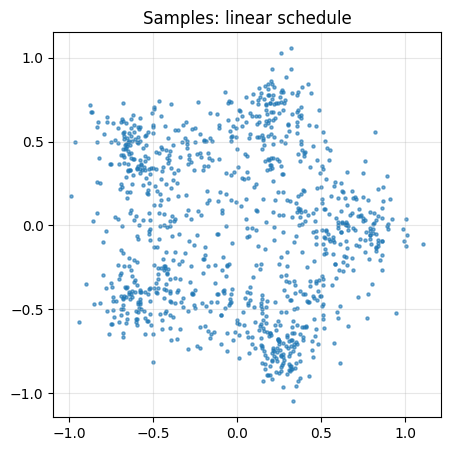

In [11]:
samples_linear = sample_vp(trainer_linear.model, config_linear, 1000)

plt.figure(figsize=(5, 5))
plt.scatter(samples_linear[:, 0], samples_linear[:, 1], s=5, alpha=0.6)
plt.title('Samples: linear schedule')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()


## Обучение VP-SDE: cosine schedule


In [12]:
config_cosine = Config()
config_cosine.schedule = 'cosine'
config_cosine.mode = 'sigma2'

trainer_cosine = VPTrainer(config_cosine)
losses['cosine'] = trainer_cosine.run()


[cosine] epoch 0: loss=0.4326
[cosine] epoch 100: loss=0.0570
[cosine] epoch 200: loss=0.0561
[cosine] epoch 300: loss=0.0545
[cosine] epoch 400: loss=0.0569
[cosine] epoch 500: loss=0.0572
[cosine] epoch 600: loss=0.0566
[cosine] epoch 700: loss=0.0566
[cosine] epoch 800: loss=0.0548
[cosine] epoch 900: loss=0.0559
[cosine] epoch 1000: loss=0.0544
[cosine] epoch 1100: loss=0.0535
[cosine] epoch 1200: loss=0.0553
[cosine] epoch 1300: loss=0.0549
[cosine] epoch 1400: loss=0.0542
[cosine] epoch 1500: loss=0.0554
[cosine] epoch 1600: loss=0.0543
[cosine] epoch 1700: loss=0.0545
[cosine] epoch 1800: loss=0.0544
[cosine] epoch 1900: loss=0.0554


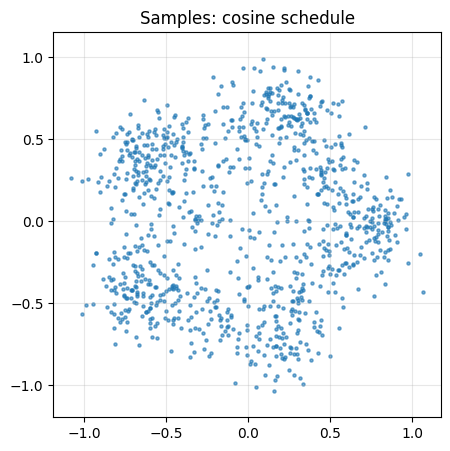

In [13]:
samples_cosine = sample_vp(trainer_cosine.model, config_cosine, 1000)

plt.figure(figsize=(5, 5))
plt.scatter(samples_cosine[:, 0], samples_cosine[:, 1], s=5, alpha=0.6)
plt.title('Samples: cosine schedule')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.show()


## Сравнение расписаний: loss и сэмплы


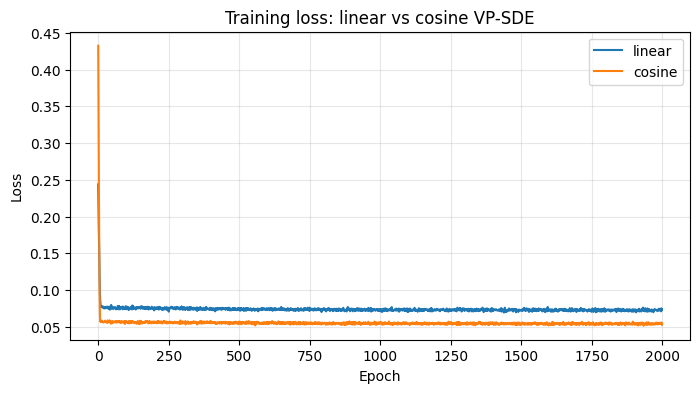

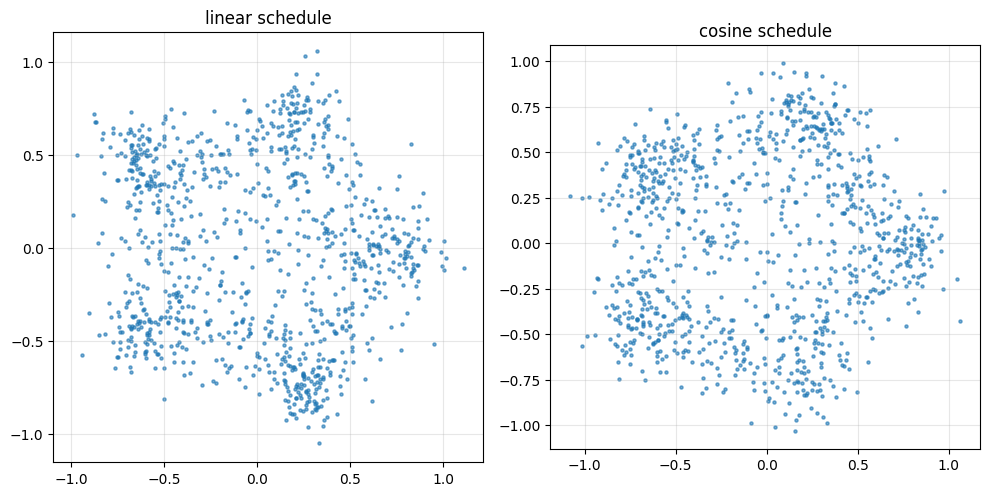

In [14]:
epochs = np.arange(len(losses['linear']))

plt.figure(figsize=(8, 4))
plt.plot(epochs, losses['linear'], label='linear')
plt.plot(epochs, losses['cosine'], label='cosine')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training loss: linear vs cosine VP-SDE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, samples, title in zip(
    axes,
    [samples_linear, samples_cosine],
    ['linear schedule', 'cosine schedule'],
):
    ax.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.6)
    ax.set_title(title)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Сравнение loss weighting (linear schedule)


In [ ]:
loss_modes = ['uniform', 'sigma2', 'beta', 'inv_sigma2']
losses_weights = {}

for mode in loss_modes:
    cfg = Config()
    cfg.schedule = 'linear'
    cfg.mode = mode
    print(f'\n=== Training with loss mode: {mode} ===')
    trainer = VPTrainer(cfg)
    losses_weights[mode] = trainer.run()

plt.figure(figsize=(9, 4))
for mode in loss_modes:
    plt.plot(losses_weights[mode], label=mode)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss weighting comparison (linear VP-SDE)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()



=== Training with loss mode: uniform ===
[linear] epoch 0: loss=0.9429
[linear] epoch 100: loss=0.5081
[linear] epoch 200: loss=0.4829
[linear] epoch 300: loss=0.4924
[linear] epoch 400: loss=0.4789
[linear] epoch 500: loss=0.4595
[linear] epoch 600: loss=0.4700
[linear] epoch 700: loss=0.4571
[linear] epoch 800: loss=0.4491
[linear] epoch 900: loss=0.4436
[linear] epoch 1000: loss=0.4516
[linear] epoch 1100: loss=0.4630
[linear] epoch 1200: loss=0.4567
[linear] epoch 1300: loss=0.4437
[linear] epoch 1400: loss=0.4539
[linear] epoch 1500: loss=0.4332
[linear] epoch 1600: loss=0.4640
[linear] epoch 1700: loss=0.4635
[linear] epoch 1800: loss=0.4415
[linear] epoch 1900: loss=0.4442

=== Training with loss mode: sigma2 ===
[linear] epoch 0: loss=0.2334
[linear] epoch 100: loss=0.0757
[linear] epoch 200: loss=0.0758
[linear] epoch 300: loss=0.0736
[linear] epoch 400: loss=0.0726
[linear] epoch 500: loss=0.0722
[linear] epoch 600: loss=0.0743
[linear] epoch 700: loss=0.0746
[linear] epoch 